# Task 1: Search algorithms


In [ ]:
import pandas as pd
import math
import time

# Load data
df = pd.read_csv("AAPL.csv")
df = df.sort_values("Date").reset_index(drop=True)

# ── Search algorithms ─────────────────────────────────────────────────────────
def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1

def jump_search(arr, target):
    n = len(arr)
    step = int(math.isqrt(n))
    prev = 0
    while prev < n and arr[min(step, n) - 1] < target:
        prev = step
        step += int(math.isqrt(n))
        if prev >= n:
            return -1
    for i in range(prev, min(step, n)):
        if arr[i] == target:
            return i
    return -1

def interpolation_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi and arr[lo] <= target <= arr[hi]:
        if arr[lo] == arr[hi]:
            return lo if arr[lo] == target else -1
        pos = lo + (hi - lo) * (target - arr[lo]) // (arr[hi] - arr[lo])
        if arr[pos] == target:
            return pos
        elif arr[pos] < target:
            lo = pos + 1
        else:
            hi = pos - 1
    return -1

# average time in ms over 3 runs 
def avg_ms(fn, arr, target):
    t0 = time.perf_counter()
    for _ in range(3):
        fn(arr, target)
    return round((time.perf_counter() - t0) / 3 * 1000, 6)

# Benchmark 
# Dates as integers (YYYYMMDD) so interpolation search can do arithmetic
dates_int = [int(d.replace("-", "")) for d in df["Date"].tolist()]

rows = []
for n in [1_000, 10_000, 50_000, 100_000]:
    arr = dates_int[:n] if n <= len(dates_int) else list(range(0, n * 10, 10))
    t   = arr[n // 2]   # target is the middle element
    rows.append({
        "n":                   n,
        "linear (ms)":        avg_ms(linear_search,        arr, t),
        "binary (ms)":        avg_ms(binary_search,        arr, t),
        "jump (ms)":          avg_ms(jump_search,          arr, t),
        "interpolation (ms)": avg_ms(interpolation_search, arr, t),
    })

results = pd.DataFrame(rows).set_index("n")
print(results)



        linear (ms)  binary (ms)  jump (ms)  interpolation (ms)
n                                                              
1000       0.016097     0.002514   0.005083            0.001167
10000      0.181319     0.002083   0.008528            0.000556
50000      1.113861     0.006986   0.019583            0.000875
100000     0.928403     0.003431   0.035639            0.000889


# Task 2: Binary Search Tree (BST) and traversals

In [63]:
import time
import csv
import random

# ------------------ NODE ------------------
class Node:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None

# ------------------ BST ------------------
class BinarySearchTree:
    def __init__(self):
        self.root = None

    # INSERT
    def insert(self, key, value):
        def _insert(node, key, value):
            if node is None:
                return Node(key, value)
            if key < node.key:
                node.left = _insert(node.left, key, value)
            elif key > node.key:
                node.right = _insert(node.right, key, value)
            return node
        self.root = _insert(self.root, key, value)

    # SEARCH
    def search(self, key):
        def _search(node, key):
            if node is None:
                return None
            if key == node.key:
                return node.value
            elif key < node.key:
                return _search(node.left, key)
            else:
                return _search(node.right, key)
        return _search(self.root, key)

    # DELETE
    def delete(self, key):
        def _min(node):
            while node.left:
                node = node.left
            return node

        def _delete(node, key):
            if node is None:
                return None

            if key < node.key:
                node.left = _delete(node.left, key)
            elif key > node.key:
                node.right = _delete(node.right, key)
            else:
                # case 1: leaf
                if node.left is None and node.right is None:
                    return None
                # case 2: one child
                if node.left is None:
                    return node.right
                if node.right is None:
                    return node.left
                # case 3: two children
                temp = _min(node.right)
                node.key = temp.key
                node.value = temp.value
                node.right = _delete(node.right, temp.key)

            return node

        self.root = _delete(self.root, key)

    # TRAVERSALS
    def inorder(self):
        res = []
        def _in(node):
            if node:
                _in(node.left)
                res.append(node.key)
                _in(node.right)
        _in(self.root)
        return res

    def preorder(self):
        res = []
        def _pre(node):
            if node:
                res.append(node.key)
                _pre(node.left)
                _pre(node.right)
        _pre(self.root)
        return res

    def postorder(self):
        res = []
        def _post(node):
            if node:
                _post(node.left)
                _post(node.right)
                res.append(node.key)
        _post(self.root)
        return res

    # BFS (queue)
    def bfs(self):
        res = []
        if not self.root:
            return res
        queue = [self.root]
        while queue:
            node = queue.pop(0)
            res.append(node.key)
            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)
        return res

    # RANGE QUERY
    def range_query(self, low, high):
        res = []
        def _range(node):
            if node is None:
                return
            if low <= node.key <= high:
                res.append(node.value)
            if node.key > low:
                _range(node.left)
            if node.key < high:
                _range(node.right)
        _range(self.root)
        return res


# ------------------ LOAD DATA ------------------
data = []
with open("AAPL.csv", newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append(row)

# FIX: shuffle to avoid recursion depth error
random.shuffle(data)

# ------------------ BUILD BST ------------------
bst = BinarySearchTree()
for row in data:
    bst.insert(row["Date"], row)

# ------------------ RANGE QUERY TEST ------------------
low = "2018-01-01"
high = "2018-12-31"

# BST timing
start = time.time()
bst_result = bst.range_query(low, high)
bst_time = time.time() - start

# Lazy baseline timing
start = time.time()
lazy_result = [row for row in data if low <= row["Date"] <= high]
lazy_time = time.time() - start

# ------------------ OUTPUT ------------------
print("BST time:", bst_time)
print("Lazy time:", lazy_time)
print("Result count:", len(bst_result))

BST time: 5.817413330078125e-05
Lazy time: 0.0005741119384765625
Result count: 251


# Task 3: Heap and top-k

In [ ]:
import time
import csv

# MIN HEAP
class MinHeap:
    def __init__(self):
        self.heap = []

    def insert(self, item):
        self.heap.append(item)
        self._heapify_up(len(self.heap) - 1)

    def extract(self):
        if len(self.heap) == 0:
            return None
        if len(self.heap) == 1:
            return self.heap.pop()

        root = self.heap[0]
        self.heap[0] = self.heap.pop()
        self._heapify_down(0)
        return root

    def peek(self):
        if self.heap:
            return self.heap[0]
        return None

    def _heapify_up(self, i):
        parent = (i - 1) // 2
        if i > 0 and self.heap[i][0] < self.heap[parent][0]:
            self.heap[i], self.heap[parent] = self.heap[parent], self.heap[i]
            self._heapify_up(parent)

    def _heapify_down(self, i):
        smallest = i
        left = 2*i + 1
        right = 2*i + 2

        if left < len(self.heap) and self.heap[left][0] < self.heap[smallest][0]:
            smallest = left
        if right < len(self.heap) and self.heap[right][0] < self.heap[smallest][0]:
            smallest = right

        if smallest != i:
            self.heap[i], self.heap[smallest] = self.heap[smallest], self.heap[i]
            self._heapify_down(smallest)

# LOAD DATA 
data = []
with open("AAPL.csv", newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append(row)

# choose a numeric column (CHANGE if needed)
key_name = "Close"   # example column

# HEAP TOP-K
k = 10
heap = MinHeap()

start = time.time()

for row in data:
    value = float(row[key_name])

    if len(heap.heap) < k:
        heap.insert((value, row))
    else:
        if value > heap.peek()[0]:
            heap.extract()
            heap.insert((value, row))

heap_time = time.time() - start

top_k_heap = [item[1] for item in heap.heap]


start = time.time()

sorted_data = sorted(data, key=lambda x: float(x[key_name]), reverse=True)
top_k_naive = sorted_data[:k]

naive_time = time.time() - start

# OUTPUT 
print("Heap time:", heap_time)
print("Naive time:", naive_time)
print("Top 10 results:")

for row in top_k_heap:
    print(row)

print("\nWhy heap is good for top-k but bad for search:")
print("- Heap is fast for keeping top-k because insert/extract are O(log k)")
print("- It only stores k elements, so it's efficient")
print("- But searching for a specific element is slow (O(n)) because heap is not fully sorted")

Heap time: 0.0039823055267333984
Naive time: 0.003236055374145508
Top 10 results:
{'Date': '2020-02-20', 'Open': '322.6300048828125', 'High': '324.6499938964844', 'Low': '318.2099914550781', 'Close': '320.29998779296875', 'Adj Close': '320.29998779296875', 'Volume': '25141500'}
{'Date': '2020-02-05', 'Open': '323.5199890136719', 'High': '324.760009765625', 'Low': '318.95001220703125', 'Close': '321.45001220703125', 'Adj Close': '320.6889343261719', 'Volume': '29706700'}
{'Date': '2020-01-30', 'Open': '320.5400085449219', 'High': '324.0899963378906', 'Low': '318.75', 'Close': '323.8699951171875', 'Adj Close': '323.1031799316406', 'Volume': '31685800'}
{'Date': '2020-02-13', 'Open': '324.19000244140625', 'High': '326.2200012207031', 'Low': '323.3500061035156', 'Close': '324.8699951171875', 'Adj Close': '324.8699951171875', 'Volume': '23686900'}
{'Date': '2020-02-10', 'Open': '314.17999267578125', 'High': '321.54998779296875', 'Low': '313.8500061035156', 'Close': '321.54998779296875', 'Ad

# Task 4: Synthesis, reflection

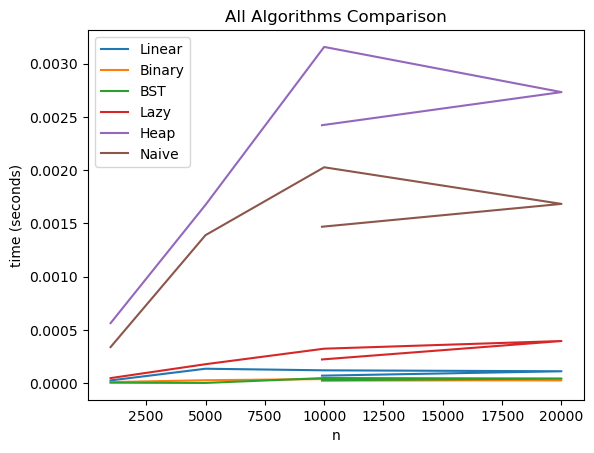

In [68]:
import time
import random
import matplotlib.pyplot as plt

# ------------------ SAFE SIZES ------------------
sizes = [1000, 5000, 10000, 20000, min(50000, len(data))]

linear_times = []
binary_times = []

bst_times = []
lazy_times = []

heap_times = []
naive_times = []

# ------------------ SEARCH FUNCTIONS ------------------
def binary_search(arr, key):
    left = 0
    right = len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid]["Date"] == key:
            return arr[mid]
        elif arr[mid]["Date"] < key:
            left = mid + 1
        else:
            right = mid - 1
    return None

def linear_search(arr, key):
    for row in arr:
        if row["Date"] == key:
            return row
    return None

# ------------------ SORTED DATA FOR BINARY ------------------
data_sorted = sorted(data, key=lambda x: x["Date"])

# ------------------ MAIN LOOP ------------------
for n in sizes:
    sample = data[:n]

    if len(sample) == 0:
        continue

    key = sample[len(sample)//2]["Date"]

    # -------- Task 1 --------
    start = time.time()
    linear_search(sample, key)
    linear_times.append(time.time() - start)

    start = time.time()
    binary_search(data_sorted[:n], key)
    binary_times.append(time.time() - start)

    # -------- Task 2 --------
    bst = BinarySearchTree()
    temp = sample.copy()
    random.shuffle(temp)

    for row in temp:
        bst.insert(row["Date"], row)

    low = "2018-01-01"
    high = "2018-12-31"

    start = time.time()
    bst.range_query(low, high)
    bst_times.append(time.time() - start)

    start = time.time()
    [row for row in sample if low <= row["Date"] <= high]
    lazy_times.append(time.time() - start)

    # -------- Task 3 --------
    k = 10
    heap = MinHeap()

    start = time.time()
    for row in sample:
        value = float(row["Close"])  # change if needed

        if len(heap.heap) < k:
            heap.insert((value, row))
        else:
            if value > heap.peek()[0]:
                heap.extract()
                heap.insert((value, row))
    heap_times.append(time.time() - start)

    start = time.time()
    sorted(sample, key=lambda x: float(x["Close"]), reverse=True)[:k]
    naive_times.append(time.time() - start)

# ------------------ PLOT ------------------
plt.plot(sizes, linear_times, label="Linear")
plt.plot(sizes, binary_times, label="Binary")

plt.plot(sizes, bst_times, label="BST")
plt.plot(sizes, lazy_times, label="Lazy")

plt.plot(sizes, heap_times, label="Heap")
plt.plot(sizes, naive_times, label="Naive")

plt.xlabel("n")
plt.ylabel("time (seconds)")
plt.title("All Algorithms Comparison")
plt.legend()
plt.show()